# Monthly Return Seasonality Analysis
**Assets:** VOO (S&P 500), IDEV (MSCI World ex USA), IEMG (MSCI EM)  
**Period:** 1987-12 ~ 2025

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

## 1. Data Loading

In [19]:
EXCLUDE_YEARS = []  # 제외할 연도 리스트 (비우면 전체 사용)

raw = pd.read_excel('data/mas_dataset.xlsx', sheet_name='data', index_col='Date')
price = raw[['VOO', 'IDEV', 'IEMG', 'VGIT']].resample('BM').last()
price = price.loc['1987-12':'2025']

ret = price.pct_change().dropna()
ret.index = pd.to_datetime(ret.index)

if EXCLUDE_YEARS:
    ret = ret[~ret.index.year.isin(EXCLUDE_YEARS)]
    print(f'Excluded years: {EXCLUDE_YEARS}')

print(f'Period: {ret.index[0].date()} ~ {ret.index[-1].date()}')
print(f'Observations: {len(ret)}')
ret.head()

Period: 1988-01-29 ~ 2025-12-31
Observations: 456


/tmp/ipykernel_34097/1099664825.py:4: FutureWarning: 'BM' is deprecated and will be removed in a future version, please use 'BME' instead.
  price = raw[['VOO', 'IDEV', 'IEMG', 'VGIT']].resample('BM').last()


,VOO,IDEV,IEMG,VGIT
Date,,,,
1988-01-29,0.042062,0.014325,0.094200,0.024558
1988-02-29,0.046615,0.065042,0.002376,0.010298
1988-03-31,-0.030893,0.059857,0.099927,-0.004401
1988-04-29,0.011060,0.013029,0.046668,-0.001600
1988-05-31,0.008649,-0.033236,0.026530,-0.004911


## 2. Average Monthly Returns by Calendar Month

In [20]:
monthly_avg = ret.groupby(ret.index.month).mean() * 100
monthly_avg.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']
monthly_avg.columns.name = None

print('Average Monthly Return (%)')
monthly_avg.round(3)

Average Monthly Return (%)


,VOO,IDEV,IEMG,VGIT
Jan,0.784,-0.095,1.415,0.545
Feb,0.335,0.468,1.256,0.162
Mar,1.061,0.508,0.976,0.162
Apr,1.694,2.522,2.666,0.192
May,1.446,0.256,0.123,0.439
Jun,0.377,-0.386,0.041,0.467
Jul,1.728,1.588,1.566,0.606
Aug,-0.290,-1.077,-1.379,0.569
Sep,-0.432,-0.673,-0.205,0.482
Oct,1.514,0.957,0.703,0.259


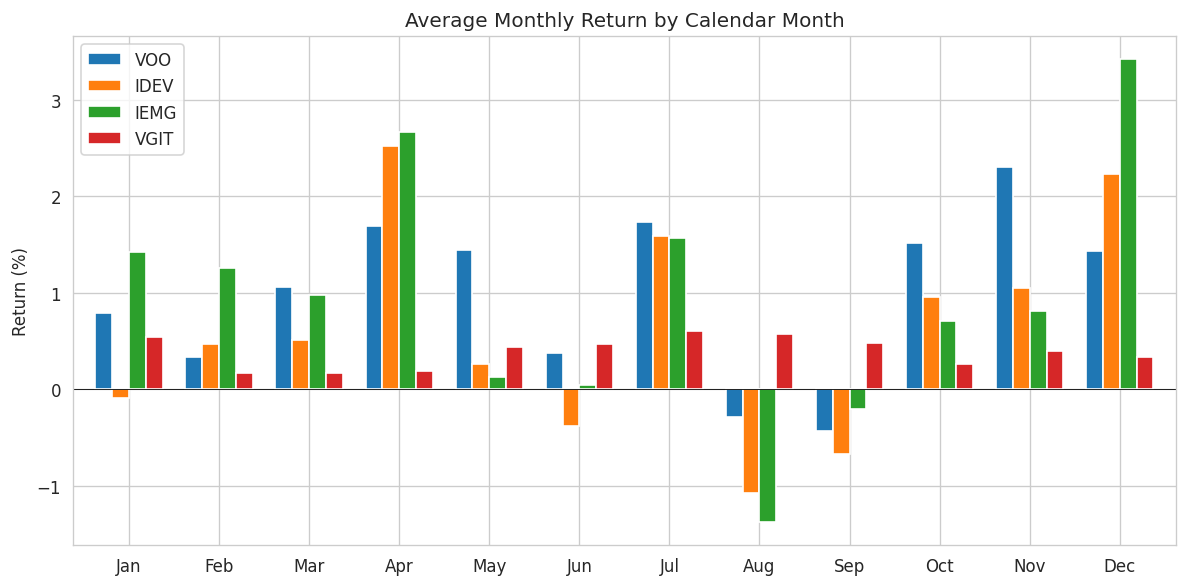

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg.plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Average Monthly Return by Calendar Month')
ax.set_ylabel('Return (%)')
ax.set_xlabel('')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Monthly Return Volatility

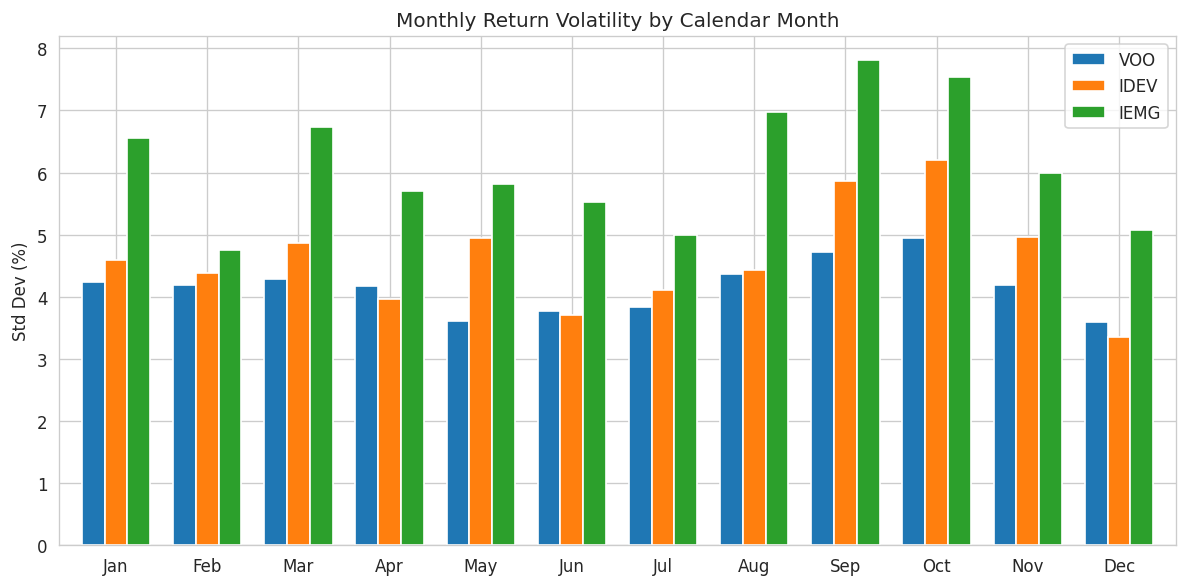

In [5]:
monthly_std = ret.groupby(ret.index.month).std() * 100
monthly_std.index = ['Jan','Feb','Mar','Apr','May','Jun',
                     'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
monthly_std.plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Monthly Return Volatility by Calendar Month')
ax.set_ylabel('Std Dev (%)')
ax.set_xlabel('')
ax.legend(frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Heatmap: Average Return

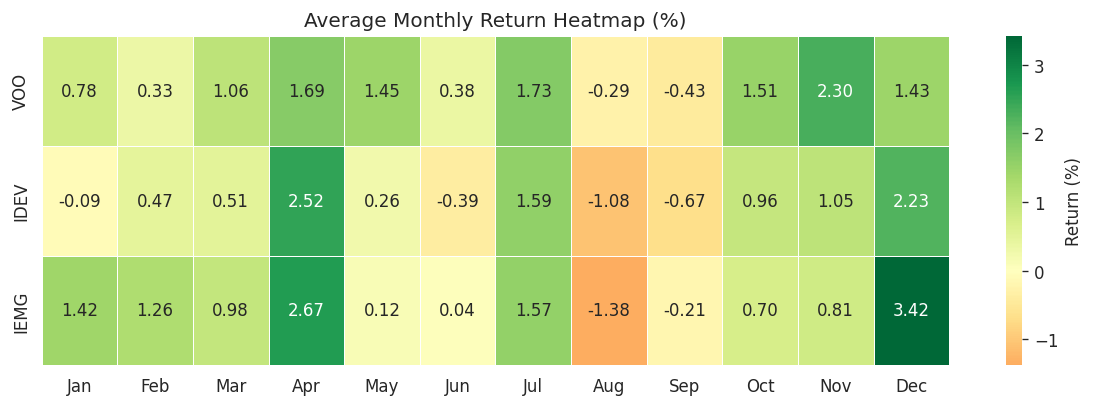

In [6]:
fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(monthly_avg.T, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Return (%)'})
ax.set_title('Average Monthly Return Heatmap (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 5. Win Rate (Positive Return Probability)

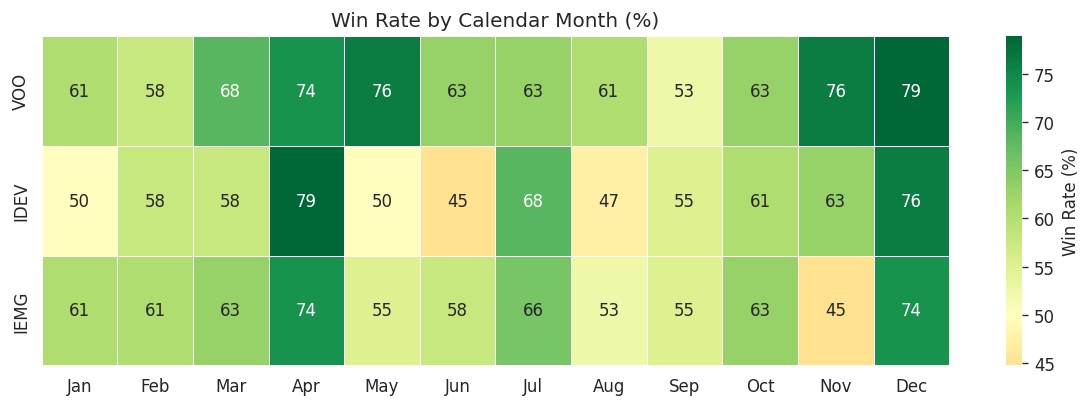

In [7]:
win_rate = ret.groupby(ret.index.month).apply(lambda x: (x > 0).mean()) * 100
win_rate.index = ['Jan','Feb','Mar','Apr','May','Jun',
                  'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(win_rate.T, annot=True, fmt='.0f', cmap='RdYlGn', center=50,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Win Rate (%)'})
ax.set_title('Win Rate by Calendar Month (%)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 6. Box Plot: Return Distribution by Month

/tmp/ipykernel_34097/427769667.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=month_labels, patch_artist=True,
/tmp/ipykernel_34097/427769667.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=month_labels, patch_artist=True,
/tmp/ipykernel_34097/427769667.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=month_labels, patch_artist=True,


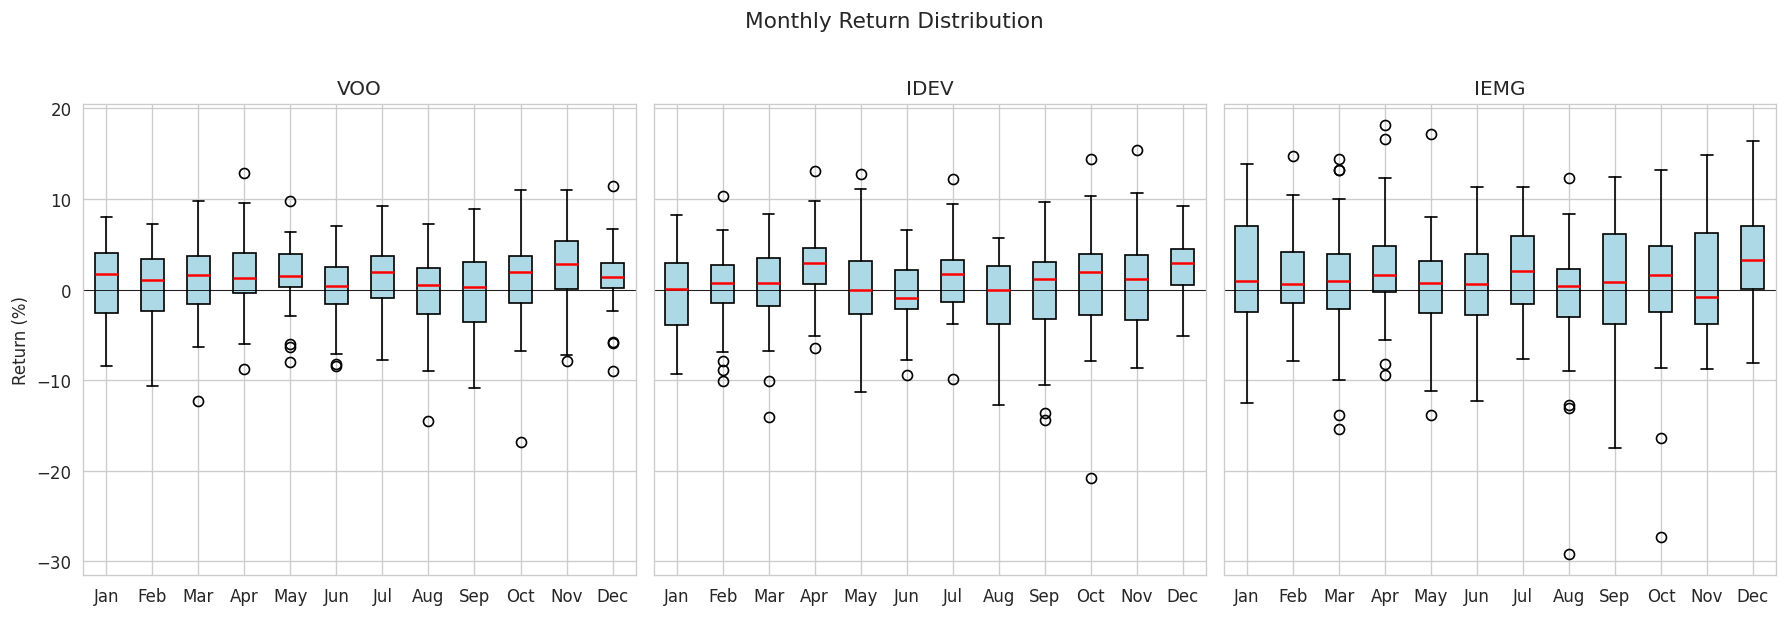

In [8]:
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
for ax, col in zip(axes, ['VOO', 'IDEV', 'IEMG']):
    data_by_month = [ret.loc[ret.index.month == m, col].values * 100 for m in range(1, 13)]
    bp = ax.boxplot(data_by_month, labels=month_labels, patch_artist=True,
                    medianprops=dict(color='red', linewidth=1.5))
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel('')
axes[0].set_ylabel('Return (%)')
fig.suptitle('Monthly Return Distribution', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 7. Statistical Test: Kruskal-Wallis (Seasonality Significance)

In [9]:
for col in ['VOO', 'IDEV', 'IEMG']:
    groups = [ret.loc[ret.index.month == m, col].values for m in range(1, 13)]
    stat, pval = stats.kruskal(*groups)
    sig = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
    print(f'{col}: H={stat:.3f}, p={pval:.4f} {sig}')

VOO: H=13.961, p=0.2351 
IDEV: H=23.417, p=0.0154 **
IEMG: H=14.630, p=0.2001 


## 8. Pairwise Difference: Seasonality Gap Between Assets

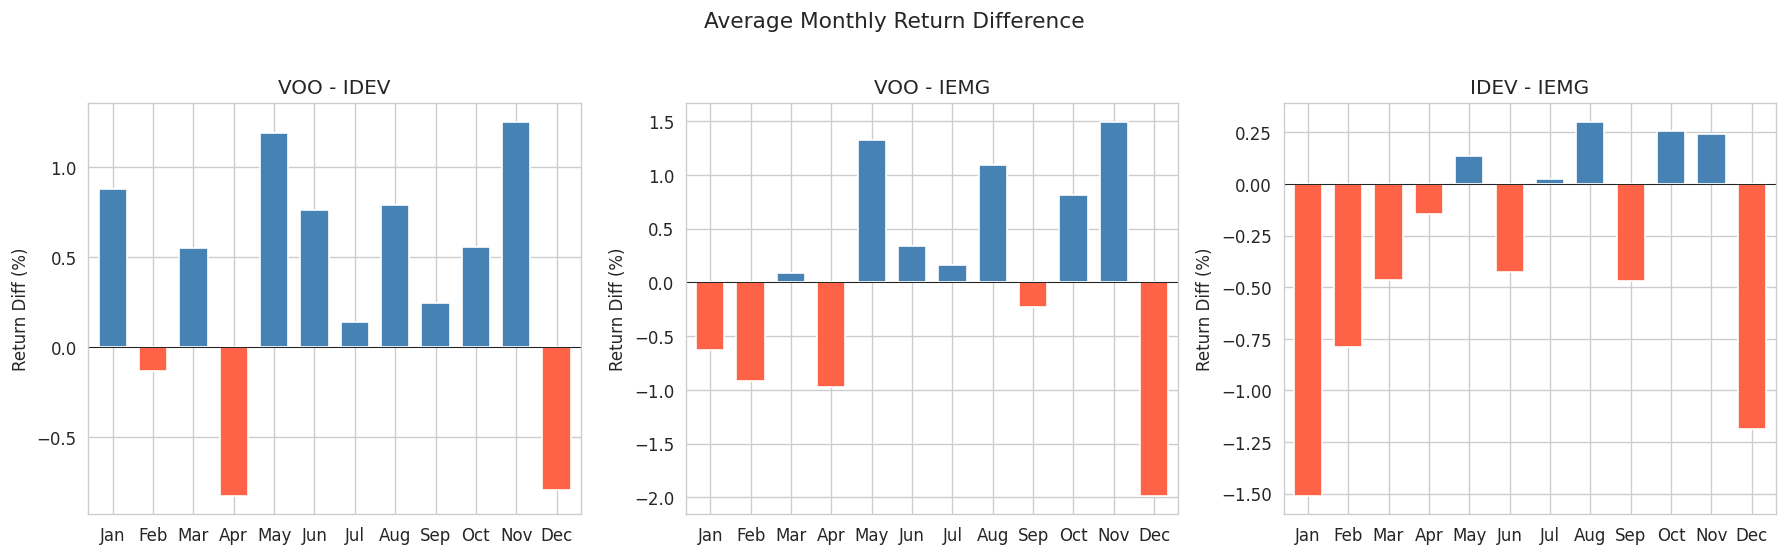

In [10]:
pairs = [('VOO', 'IDEV'), ('VOO', 'IEMG'), ('IDEV', 'IEMG')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (a, b) in zip(axes, pairs):
    diff = (ret[a] - ret[b]) * 100
    diff_avg = diff.groupby(diff.index.month).mean()
    diff_avg.index = month_labels
    colors = ['steelblue' if v >= 0 else 'tomato' for v in diff_avg]
    diff_avg.plot(kind='bar', ax=ax, color=colors, width=0.7)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_title(f'{a} - {b}')
    ax.set_ylabel('Return Diff (%)')
    ax.set_xlabel('')
    plt.sca(ax)
    plt.xticks(rotation=0)
fig.suptitle('Average Monthly Return Difference', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

## 9. Cumulative Return by Calendar Month (Sell in May?)

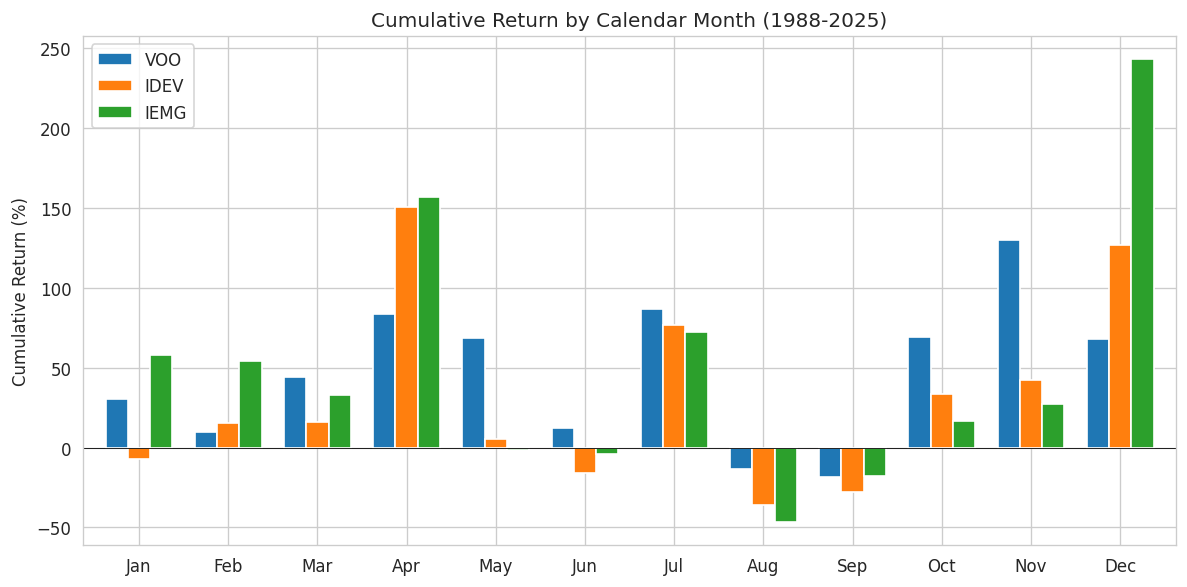

In [11]:
cumret_by_month = ret.groupby(ret.index.month).apply(
    lambda x: ((1 + x).prod() - 1) * 100
)
cumret_by_month.index = month_labels

fig, ax = plt.subplots(figsize=(10, 5))
cumret_by_month.plot(kind='bar', ax=ax, width=0.75)
ax.set_title('Cumulative Return by Calendar Month (1988-2025)')
ax.set_ylabel('Cumulative Return (%)')
ax.set_xlabel('')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(frameon=True)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()